# Neuroglancer Annotation Pipeline

This notebook provides a workflow to:
1.  Generate a Neuroglancer link for a specific neuron.
2.  Annotate points in 3D (Spines vs. Non-Spines).
3.  Ingest the annotations back into Python.
4.  **Snap** these 3D points to the nearest mesh vertex.
5.  **Map** the vertices to HKS Segment IDs.
6.  **Export** a Machine Learning dataset (X=HKS features, y=Labels).

In [2]:
!pip install nglui
import numpy as np
import pandas as pd
from caveclient import CAVEclient
from meshparty import trimesh_io
from meshmash import condensed_hks_pipeline
import annotation_utils # Our new helper module

# --- CONFIGURATION ---
dataset_name = 'minnie65_public'
materialization = 1300
CACHE_DIR = 'meshes'
target_id = 864691135724233643 # Example Neuron ID

# Setup Client
client = CAVEclient(dataset_name)
client.version = materialization

mm = trimesh_io.MeshMeta(
    cv_path=client.info.segmentation_source(),
    disk_cache_path=CACHE_DIR
)


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: C:\Users\bkrou\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable


## Step 1: Generate Neuroglancer Link
Click the link below to open Neuroglancer. Use the 'annotations' layer to add points:
-   **Spines**: Add points to spines you want to label.
-   **Control**: You can optionally add points to dendrites/somas for negative labels.

In [3]:
# link = annotation_utils.generate_ng_link(target_id, client)
# try:
#     from IPython.display import display, HTML
#     display(HTML(f'<a href="{link}" target="_blank">OPEN NEUROGLANCER</a>'))
# except:
#     print(link)

# import caveclient
# from nglui import statebuilder

# client = caveclient.CAVEclient('minnie65_public')

# # Get a root id of a specific neuron
# root_id = client.materialize.query_table(
#     'nucleus_detection_v0',
#     filter_equal_dict={'id': target_id}
# )['pt_root_id']

# statebuilder.helpers.make_neuron_neuroglancer_link(
#     client,
#     root_id,
#     show_inputs=True,
#     show_outputs=True,
# )

import importlib
import annotation_utils
importlib.reload(annotation_utils)
from caveclient import CAVEclient

# 1. Setup client
client = CAVEclient('minnie65_public')

# 2. Your target neuron
target_id = 864691135724233643

# 3. Generate the link — this uses the OFFICIAL nglui helper
link = annotation_utils.generate_ng_link(target_id, client)

print("CLICK TO OPEN NEUROGLANCER:")
print(link)

CLICK TO OPEN NEUROGLANCER:
CAVEclient<datastack_name=minnie65_public, server_address=https://global.daf-apis.com>#!%7B%22position%22:%5B218809.0,161359.0,13929.0%5D,%22layout%22:%22xy-3d%22,%22dimensions%22:%7B%22x%22:%5B4e-09,%22m%22%5D,%22y%22:%5B4e-09,%22m%22%5D,%22z%22:%5B4e-08,%22m%22%5D%7D,%22crossSectionScale%22:1.0,%22projectionScale%22:50000.0,%22showSlices%22:false,%22layers%22:%5B%7B%22type%22:%22image%22,%22source%22:%5B%7B%22url%22:%22precomputed://https://bossdb-open-data.s3.amazonaws.com/iarpa_microns/minnie/minnie65/em%22,%22transform%22:%7B%22outputDimensions%22:%7B%22x%22:%5B4e-09,%22m%22%5D,%22y%22:%5B4e-09,%22m%22%5D,%22z%22:%5B4e-08,%22m%22%5D%7D%7D,%22subsources%22:%7B%7D,%22enableDefaultSubsources%22:true%7D%5D,%22name%22:%22imagery%22%7D,%7B%22type%22:%22segmentation%22,%22source%22:%5B%7B%22url%22:%22precomputed://https://storage.googleapis.com/iarpa_microns/minnie/minnie65/seg_m1300%22,%22transform%22:%7B%22outputDimensions%22:%7B%22x%22:%5B4e-09,%22m%22%5D,%

In [4]:
import os
from caveclient import CAVEclient
from nglui import parser

client = CAVEclient('minnie65_public')

state_id = 5560000195854336
state_json = client.state.get_state_json(state_id)
state = parser.StateParser(state_json)

state.layer_dataframe()

,layer,type,source,archived
0,img,image,precomputed://https://bossdb-open-data.s3.amaz...,False
1,seg,segmentation_with_graph,graphene://https://minnie.microns-daf.com/segm...,False
2,syns_in,annotation,None,False
3,syns_out,annotation,None,False


In [5]:
state.annotation_dataframe()

,layer,anno_type,point,pointB,linked_segmentation,tags,anno_id,group_id,description
0,syns_in,point,"[294095, 196476, 24560]",NaN,[864691136333760691],[],b832a0b7fe04a34195fef0fbc6743260e389e68e,None,None
1,syns_in,point,"[294879, 196374, 24391]",NaN,[864691136333760691],[],09ac4a97322131421d292d96a13ecbeb52dea50a,None,None
2,syns_in,point,"[300246, 200562, 24297]",NaN,[864691136333760691],[],a9f1c484bbe037d3571525748455c19e6d792652,None,None
3,syns_in,point,"[300894, 201844, 24377]",NaN,[864691136333760691],[],2efe4f45ad2b1f8e11da480a205a907ae5224c21,None,None
4,syns_in,point,"[294742, 199552, 23392]",NaN,[864691136333760691],[],00661afd142462468d74167c2857c1d3f64b6870,None,None
...,...,...,...,...,...,...,...,...,...
5272,syns_out,point,"[277152, 200746, 22723]",NaN,[864691132294257136],[],92fce4b77aa345ad0c5c9e7c2d568b5de9aaa274,None,None
5273,syns_out,point,"[298884, 189782, 21453]",NaN,[864691132135519710],[],7aafe74e6a4be5daf64c4f21439ed1788faf0ef0,None,None
5274,syns_out,point,"[330182, 198986, 23862]",NaN,[864691132100215248],[],7f250c09e29df2a498236b9177292c0c68ac36f1,None,None
5275,syns_out,point,"[326552, 186446, 24792]",NaN,[864691131892380409],[],4199c5a222e64a13976d6628d91eea4807a4fd90,None,None


In [6]:
parser.tag_dictionary(state_json, layer_name='syns_out')


{1: 'targets_spine', 2: 'targets_shaft', 3: 'targets_soma'}

In [7]:
state.annotation_dataframe(expand_tags=True, split_points=True, point_resolution=[1,1,1])


,layer,anno_type,point,linked_segmentation,tags,anno_id,group_id,description,point_x,point_y,point_z,pointB_x,pointB_y,pointB_z,targets_spine,targets_shaft,targets_soma
0,syns_in,point,NaN,[864691136333760691],[],b832a0b7fe04a34195fef0fbc6743260e389e68e,None,None,1176380.0,785904.0,982400.0,NaN,NaN,NaN,NaN,NaN,NaN
1,syns_in,point,NaN,[864691136333760691],[],09ac4a97322131421d292d96a13ecbeb52dea50a,None,None,1179516.0,785496.0,975640.0,NaN,NaN,NaN,NaN,NaN,NaN
2,syns_in,point,NaN,[864691136333760691],[],a9f1c484bbe037d3571525748455c19e6d792652,None,None,1200984.0,802248.0,971880.0,NaN,NaN,NaN,NaN,NaN,NaN
3,syns_in,point,NaN,[864691136333760691],[],2efe4f45ad2b1f8e11da480a205a907ae5224c21,None,None,1203576.0,807376.0,975080.0,NaN,NaN,NaN,NaN,NaN,NaN
4,syns_in,point,NaN,[864691136333760691],[],00661afd142462468d74167c2857c1d3f64b6870,None,None,1178968.0,798208.0,935680.0,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5272,syns_out,point,NaN,[864691132294257136],[],92fce4b77aa345ad0c5c9e7c2d568b5de9aaa274,None,None,1108608.0,802984.0,908920.0,NaN,NaN,NaN,False,False,False
5273,syns_out,point,NaN,[864691132135519710],[],7aafe74e6a4be5daf64c4f21439ed1788faf0ef0,None,None,1195536.0,759128.0,858120.0,NaN,NaN,NaN,False,False,False
5274,syns_out,point,NaN,[864691132100215248],[],7f250c09e29df2a498236b9177292c0c68ac36f1,None,None,1320728.0,795944.0,954480.0,NaN,NaN,NaN,False,False,False
5275,syns_out,point,NaN,[864691131892380409],[],4199c5a222e64a13976d6628d91eea4807a4fd90,None,None,1306208.0,745784.0,991680.0,NaN,NaN,NaN,False,False,False


In [8]:
from nglui import statebuilder
statebuilder.site_utils.set_default_config(target_site='spelunker')

client.version=1412

AttributeError: module 'nglui.statebuilder.site_utils' has no attribute 'set_default_config'

## Step 2: Load Mesh & Compute/Load HKS
We need the mesh and its HKS features to map our annotations.

In [ ]:
print(f"Loading mesh for {target_id}...")
mesh = mm.mesh(seg_id=target_id)

# Run HKS Pipeline (or load if cached - implementing cache logic recommended later)
print("Computing HKS features (this might take a moment)...")
mesh_tuple = (mesh.vertices.astype(np.float32), mesh.faces)
res = condensed_hks_pipeline(
    mesh_tuple, 
    simplify_target_reduction=0.7, 
    distance_threshold=3.0,
    verbose=False
)

# EXTRACT CRITICAL DATA
# 1. The HKS Features per Segment
hks_df = res.condensed_features # Index is usually 0, 1, 2... corresponding to segments

# 2. The simplified mesh vertices (to snap to)
simple_vertices, simple_faces = res.simple_mesh

# 3. Mapping from Vertex Index -> Segment ID
vertex_to_segment = res.simple_labels

print(f"Ready. Mesh has {len(simple_vertices)} vertices and {len(hks_df)} segments.")

NameError: name 'target_id' is not defined

## Step 3: Ingest Annotations & Snap to Mesh
Paste your Neuroglancer JSON state here (or load from file).

In [ ]:
# PASTE JSON HERE
ng_state = {
    # ... paste the full JSON from Neuroglancer here ...
    # dictionary with 'layers': [ ... ]
}

# 1. Extract Points
raw_points = annotation_utils.extract_points_from_ng_state(ng_state, layer_name='annotations')

if len(raw_points) > 0:
    # Neuroglancer points are often in voxel coordinates. 
    # Check if they match mesh units (nm). 
    # If using CAVE/CloudVolume defaults, they might be in 4x4x40nm voxels or similar.
    # adjustments might be needed depending on how the layer was set up.
    # Assuming here points are in NM if view state was consistent, or voxels.
    # TODO: Add explicit unit conversion if needed.
    
    # 2. Snap to Mesh
    dists, v_indices = annotation_utils.snap_points_to_mesh(simple_vertices, raw_points)
    
    print(f"Extracted {len(raw_points)} points. Max distance to mesh: {dists.max():.2f}")
    
    # 3. Map to Segments
    target_segments = annotation_utils.map_indices_to_segments(v_indices, vertex_to_segment)
    
    print(f"Mapped to {len(np.unique(target_segments))} unique segments.")
else:
    print("No points found in state!")

## Step 4: Create ML Dataset (X, y)
We will now fetch the HKS features (X) for these segments and assign label 1 (Spine).

In [ ]:
if len(raw_points) > 0:
    # Create Dataset (Assuming label=1 for these points)
    Xy_df, missing = annotation_utils.create_training_dataset(target_segments, hks_df, label_value=1)
    
    print(f"Created dataset with {len(Xy_df)} samples.")
    if missing:
        print(f"Warning: {len(missing)} segments resulted in missing HKS features.")
        
    # Preview
    print(Xy_df.head())
    
    # Save
    Xy_df.to_csv('spine_training_data.csv', index=False)
    print("Saved to spine_training_data.csv")

In [14]:
import pandas as pd
import numpy as np
import ast
import scipy.spatial
from caveclient import CAVEclient
from meshparty import trimesh_io
from meshmash import condensed_hks_pipeline

def generate_hks_from_csv(csv_path, client):
    # 1. Load CSV
    df = pd.read_csv(csv_path)
    
    def parse_coord(s):
        try: return np.array(ast.literal_eval(s))
        except: return None

    df['voxel_coord'] = df['Coordinate 1'].apply(parse_coord)
    df = df.dropna(subset=['voxel_coord', 'Segment IDs'])
    
    # 2. Map Voxel Segment IDs to Current Root IDs (CRITICAL)
    # This ensures we get the mesh for the whole neuron, not just a fragment.
    # We use the current materialization version set in the client.
    print("Mapping Segment IDs to current Root IDs...")
    unique_segs = df['Segment IDs'].unique()
    # Get the top-most merged ID (Root ID) for each segment fragment
    root_mapping = {seg: client.chunkedgraph.get_root_id(int(seg)) for seg in unique_segs}
    df['Current Root ID'] = df['Segment IDs'].map(root_mapping)

    # 3. Setup Voxel to NM conversion
    # standard minnie65 resolution: 4x4x40 nm
    res_factor = np.array([4, 4, 40])
    
    all_X = []
    all_y = []

    # 4. Iterate through unique Root IDs
    unique_roots = df['Current Root ID'].unique()
    mm = trimesh_io.MeshMeta(cv_path=client.info.segmentation_source(), disk_cache_path='meshes')

    for root_id in unique_roots:
        cell_df = df[df['Current Root ID'] == root_id]
        print(f"\nProcessing Root ID: {root_id} ({len(cell_df)} annotations)")
        
        try:
            # COORDINATE CONSISTENCY: 
            # Input voxel tuple -> Physical NM array for KDTree snapping
            query_pts_nm = np.stack(cell_df['voxel_coord'].values) * res_factor
            labels = cell_df['Tags'].values

            # Fetch Mesh using Root ID
            mesh = mm.mesh(seg_id=root_id)
            mesh.add_link_edges(seg_id=root_id, client=client.chunkedgraph)

            # Compute HKS (Operating on mesh vertices which are also in NM)
            hks_res = condensed_hks_pipeline(
                (mesh.vertices.astype(np.float32), mesh.faces), 
                verbose=False
            )

            # 5. Snap labels to mesh
            # mesh.vertices are in NM, query_pts_nm are in NM. Match!
            tree = scipy.spatial.KDTree(mesh.vertices)
            _, vertex_indices = tree.query(query_pts_nm)

            # 6. Map mesh index to HKS features
            node_ids = hks_res.labels[vertex_indices]
            valid_mask = node_ids != -1
            
            if any(valid_mask):
                # Using .loc to grab the rows from the HKS feature matrix
                X_part = hks_res.condensed_features.loc[node_ids[valid_mask]].values
                y_part = labels[valid_mask]

                all_X.append(X_part)
                all_y.append(y_part)
            
        except Exception as e:
            print(f"Error processing Root ID {root_id}: {e}")

    # 7. Stack results
    if not all_X:
        raise ValueError("Pipeline failed to extract any HKS features.")

    X = np.vstack(all_X)
    y = np.concatenate(all_y)

    print(f"\nWorkflow Complete!")
    print(f"X (HKS Features): {X.shape}")
    print(f"y (Labels): {y.shape}")
    
    return X, y

# --- Execute ---
client = CAVEclient('minnie65_public')
csv_file = 'annotations.csv'
X, y = generate_hks_from_csv(csv_file, client)

Mapping Segment IDs to current Root IDs...

Processing Root ID: 864691134149139743 (3 annotations)



Processing Root ID: 864691135716006150 (2 annotations)



Processing Root ID: 864691135158987762 (2 annotations)



Processing Root ID: 864691135617699731 (2 annotations)



Processing Root ID: 864691134900263749 (2 annotations)


...


Processing Root ID: 864691136380321646 (1 annotations)



Processing Root ID: 864691136381082990 (1 annotations)



Processing Root ID: 864691136382772590 (1 annotations)



Processing Root ID: 864691136521606801 (1 annotations)


KeyboardInterrupt: 

# Manual Annotation of 1 neuron

In [ ]:
import pandas as pd
import numpy as np
import ast
import scipy.spatial
from caveclient import CAVEclient
from meshparty import trimesh_io
from meshmash import condensed_hks_pipeline

def generate_hks_single_cell(csv_path, client, master_root_id):
    """
    Downloads ONLY ONE mesh (the master_root_id) and maps all 200+ 
    annotations to it, regardless of the Segment ID in the CSV.
    """
    # 1. Load CSV and Parse Coordinates
    df = pd.read_csv(csv_path)
    
    def parse_coord(s):
        try: return np.array(ast.literal_eval(s))
        except: return None

    df['voxel_coord'] = df['Coordinate 1'].apply(parse_coord)
    df = df.dropna(subset=['voxel_coord'])
    
    # 2. Setup Voxel to NM conversion (4x4x40nm)
    res_factor = np.array([4, 4, 40])
    query_pts_nm = np.stack(df['voxel_coord'].values) * res_factor
    labels = df['Tags'].values

    # 3. DOWNLOAD MESH ONCE
    print(f"Downloading ONE mesh for Master Root ID: {master_root_id}")
    mm = trimesh_io.MeshMeta(cv_path=client.info.segmentation_source(), disk_cache_path='meshes')
    mesh = mm.mesh(seg_id=master_root_id)
    mesh.add_link_edges(seg_id=master_root_id, client=client.chunkedgraph)

    # 4. COMPUTE HKS ONCE
    print("Computing HKS for the entire neuron... (This takes a minute but only happens once)")
    hks_res = condensed_hks_pipeline((mesh.vertices.astype(np.float32), mesh.faces), verbose=True)

    # 5. SNAP ALL 200 POINTS AT ONCE
    print(f"Mapping all {len(query_pts_nm)} annotations to the neuron surface...")
    tree = scipy.spatial.KDTree(mesh.vertices)
    _, vertex_indices = tree.query(query_pts_nm)
    
    # Resolve high-res vertex indices to HKS feature rows
    node_ids = hks_res.labels[vertex_indices]
    
    # 6. Build the Final Table
    valid_mask = node_ids != -1
    X = hks_res.condensed_features.loc[node_ids[valid_mask]].values
    y = labels[valid_mask]

    # Create the single DataFrame
    hks_cols = [f"hks_t{i}" for i in range(X.shape[1])]
    df_final = pd.DataFrame(X, columns=hks_cols)
    df_final['target_label'] = y
    
    print(f"SUCCESS: Created table with {df_final.shape[0]} rows and {df_final.shape[1]} columns.")
    return df_final

# --- EXECUTION ---
client = CAVEclient('minnie65_public')

# INPUT: Your actual Master Root ID for the neuron
my_neuron_id = 864691135724233643 

df_training = generate_hks_single_cell('annotations.csv', client, my_neuron_id)

# Save the final consolidated table
df_training.to_csv("master_training_data.csv", index=False)

Computing HKS for the entire neuron... (This takes a minute but only happens once)
Subdividing mesh...
Meshes in queue: 1
Finding overlapping submeshes...
Computing HKS across submeshes...


Applying function compute_condensed_hks:   0%|          | 0/7 [00:00<?, ?it/s]

Mapping all 214 annotations to the neuron surface...
SUCCESS: Created table with 214 rows and 33 columns.


In [47]:
# Load master_training_data.csv
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import accuracy_score, classification_report

# Define your target classes
valid_classes = ['Soma', 'Shaft', 'Spine']

# Filter the dataframe to only include rows with these labels
df_training = df_training[df_training['target_label'].isin(valid_classes)]

X, y = df_training.iloc[:,:-1], df_training.iloc[:,-1]

# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state = 42)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

fold_accuracies = []
all_y_true = []
all_y_pred = []
print(f"Starting Stratified 5-Fold Cross-Validation...")
print("-" * 30)
# 3. Cross-Validation Loop
for fold, (train_idx, test_idx) in enumerate(skf.split(X, y), 1):
    # Split the data
    X_train_fold, X_test_fold = X.iloc[train_idx], X.iloc[test_idx]
    y_train_fold, y_test_fold = y.iloc[train_idx], y.iloc[test_idx]

    clf = RandomForestClassifier(n_estimators = 100, max_depth=5, random_state=42, oob_score=True)
    clf.fit(X_train_fold, y_train_fold)
    
    # Evaluate
    y_pred = clf.predict(X_test_fold)
    acc = accuracy_score(y_test_fold, y_pred)
    fold_accuracies.append(acc)
    all_y_true.extend(y_test_fold)
    all_y_pred.extend(y_pred)

# print(f"Model Accuracy: {clf.score(X_test, y_test):.2%}")
# 4. Final Summary
print("-" * 30)
print(f"Average Stratified Accuracy: {np.mean(fold_accuracies):.2%}")
print(f"Standard Deviation:         {np.std(fold_accuracies):.2%}")
# Optional: Show final classification report for the last fold
print("\nFinal Fold Classification Report:")
print(classification_report(y_test_fold, y_pred))


Starting Stratified 5-Fold Cross-Validation...
------------------------------
------------------------------
Average Stratified Accuracy: 93.75%
Standard Deviation:         5.54%

Final Fold Classification Report:
              precision    recall  f1-score   support

       Shaft       0.83      0.91      0.87        11
        Soma       1.00      1.00      1.00         8
       Spine       0.95      0.91      0.93        22

    accuracy                           0.93        41
   macro avg       0.93      0.94      0.93        41
weighted avg       0.93      0.93      0.93        41



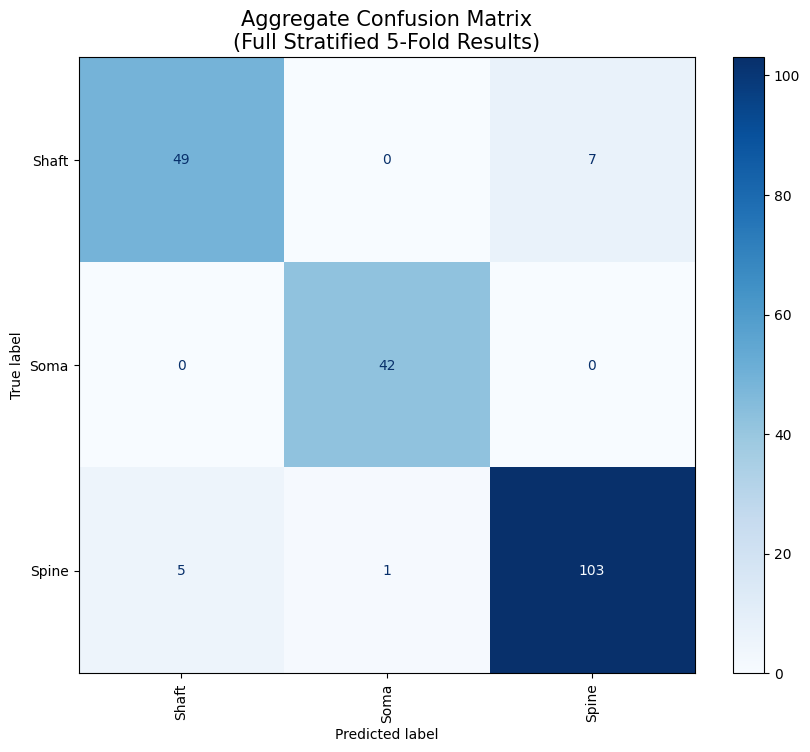

In [48]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

# Create a high-quality visualization of results from ALL folds
fig, ax = plt.subplots(figsize=(10, 8))

# from_predictions is used here because we aggregated the results in the loop above
cmp = ConfusionMatrixDisplay.from_predictions(
    all_y_true, 
    all_y_pred, 
    display_labels=clf.classes_, # Uses the labels from the last trained model
    cmap='Blues',                # Using a higher-contrast vibrant palette
    xticks_rotation='vertical',
    ax=ax
)

plt.title("Aggregate Confusion Matrix\n(Full Stratified 5-Fold Results)", fontsize=15)
plt.grid(False) 
plt.show()


In [43]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, classification_report
import numpy as np

# 1. Prepare data
X, y = df_training.iloc[:,:-1], df_training.iloc[:,-1]

# 2. Split data (oob_score is NOT a parameter here)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Train Classifier (oob_score belongs here)
clf = RandomForestClassifier(random_state=42, oob_score=True)
clf.fit(X_train, y_train)

# 4. Predictions for metrics
y_pred = clf.predict(X_test)
y_prob = clf.predict_proba(X_test)

# 5. Print Metrics
print(f"Model Accuracy: {clf.score(X_test, y_test):.2%}")
print(f"Precision:      {precision_score(y_test, y_pred, average='weighted'):.2%}")
print(f"Recall:         {recall_score(y_test, y_pred, average='weighted'):.2%}")
print(f"F1 Score:       {f1_score(y_test, y_pred, average='weighted'):.2%}")

# AUC calculation (handles binary and multi-class)
try:
    if len(np.unique(y_test)) == 2:
        auc = roc_auc_score(y_test, y_prob[:, 1])
    else:
        auc = roc_auc_score(y_test, y_prob, multi_class='ovr')
    print(f"ROC AUC:        {auc:.2%}")
except Exception as e:
    print(f"Could not calculate ROC AUC: {e}")

print(f"OOB Score:       {clf.oob_score_:.2%}")

print("\nFull Classification Report:")
print(classification_report(y_test, y_pred))


Model Accuracy: 90.48%
Precision:      90.48%
Recall:         90.48%
F1 Score:       90.48%
ROC AUC:        98.82%
OOB Score:       92.73%

Full Classification Report:
              precision    recall  f1-score   support

       Shaft       0.83      0.83      0.83        12
        Soma       1.00      1.00      1.00         8
       Spine       0.91      0.91      0.91        22

    accuracy                           0.90        42
   macro avg       0.91      0.91      0.91        42
weighted avg       0.90      0.90      0.90        42



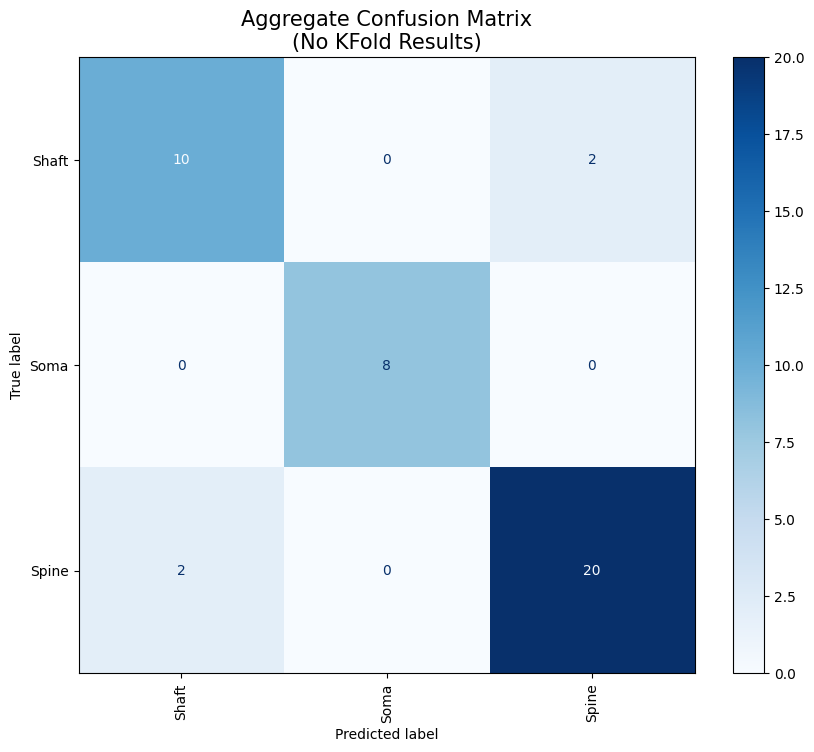

In [46]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

# Create a high-quality visualization of results from ALL folds
fig, ax = plt.subplots(figsize=(10, 8))

# from_predictions is used here because we aggregated the results in the loop above
cmp = ConfusionMatrixDisplay.from_predictions(
    y_test, 
    y_pred, 
    display_labels=clf.classes_, # Uses the labels from the last trained model
    cmap='Blues',                # Using a higher-contrast vibrant palette
    xticks_rotation='vertical',
    ax=ax
)

plt.title("Aggregate Confusion Matrix\n(No KFold Results)", fontsize=15)
plt.grid(False) 
plt.show()

In [33]:
df_training['target_label'].value_counts()

target_label
Spine    109
Shaft     56
Soma      42
Name: count, dtype: int64

In [4]:
!pip install umap-learn

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: C:\Users\bkrou\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


C:\Users\bkrou\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


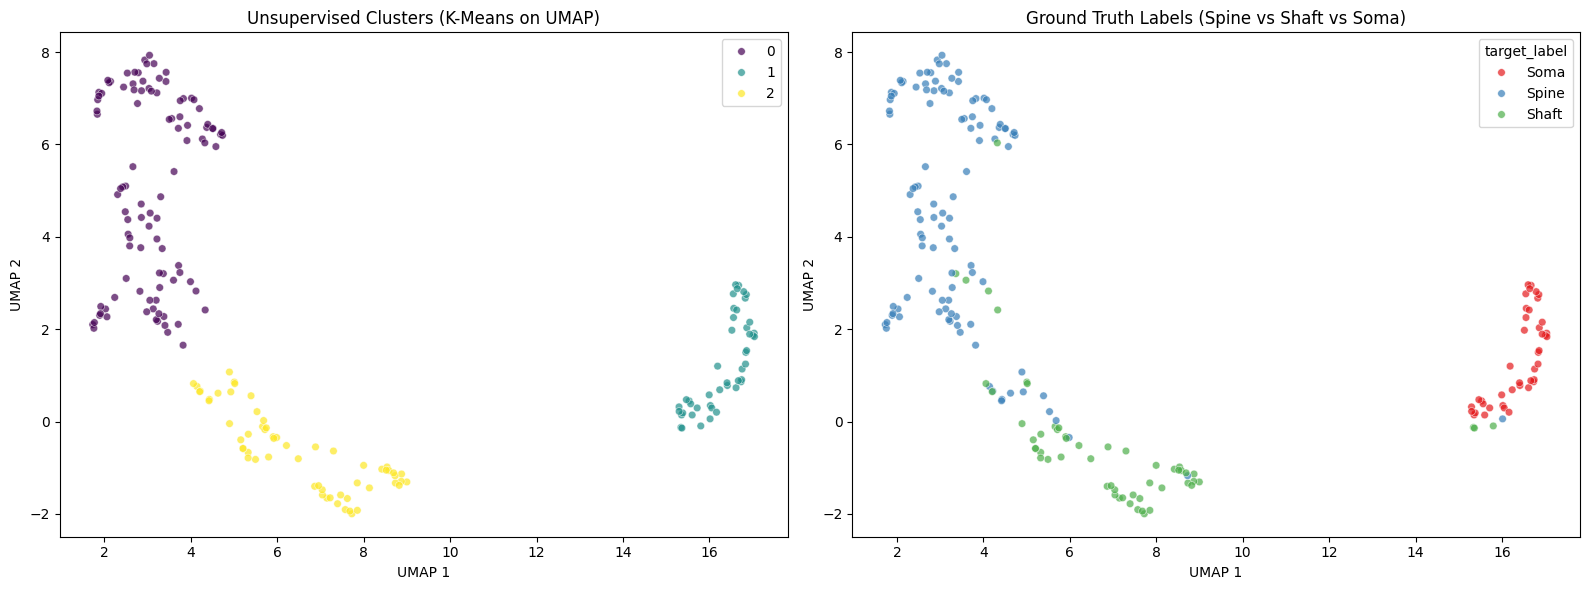

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import umap
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# --- 1. Load Your Data ---
# Replace these with your actual HKS feature matrix and labels
# X should be shape (n_samples, n_hks_time_steps)
# y should be a list/array of strings ['Spine', 'Shaft', 'Soma'...]

# Example placeholder for demonstration:
# X = hks_matrix 
# y = labels

def plot_umap_comparison(X, y, n_neighbors=15, min_dist=0.1):
    # Standardize HKS values (Crucial for UMAP/Clustering)
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # --- 2. Run UMAP ---
    reducer = umap.UMAP(n_neighbors=n_neighbors, 
                        min_dist=min_dist, 
                        metric='euclidean', 
                        random_state=42)
    embedding = reducer.fit_transform(X_scaled)

    # --- 3. Unsupervised Clustering (K-Means) ---
    # We choose 3 clusters to see if they match your 3 labels
    kmeans = KMeans(n_clusters=3, random_state=42)
    clusters = kmeans.fit_predict(embedding)

    # --- 4. Visualization ---
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

    # Plot A: Unsupervised Clusters
    sns.scatterplot(x=embedding[:, 0], y=embedding[:, 1], 
                    hue=clusters, palette='viridis', ax=ax1, s=30, alpha=0.7)
    ax1.set_title("Unsupervised Clusters (K-Means on UMAP)")
    ax1.set_xlabel("UMAP 1")
    ax1.set_ylabel("UMAP 2")

    # Plot B: Ground Truth Labels
    sns.scatterplot(x=embedding[:, 0], y=embedding[:, 1], 
                    hue=y, palette='Set1', ax=ax2, s=30, alpha=0.7)
    ax2.set_title("Ground Truth Labels (Spine vs Shaft vs Soma)")
    ax2.set_xlabel("UMAP 1")
    ax2.set_ylabel("UMAP 2")

    plt.tight_layout()
    plt.show()

# To run:
plot_umap_comparison(X, y)

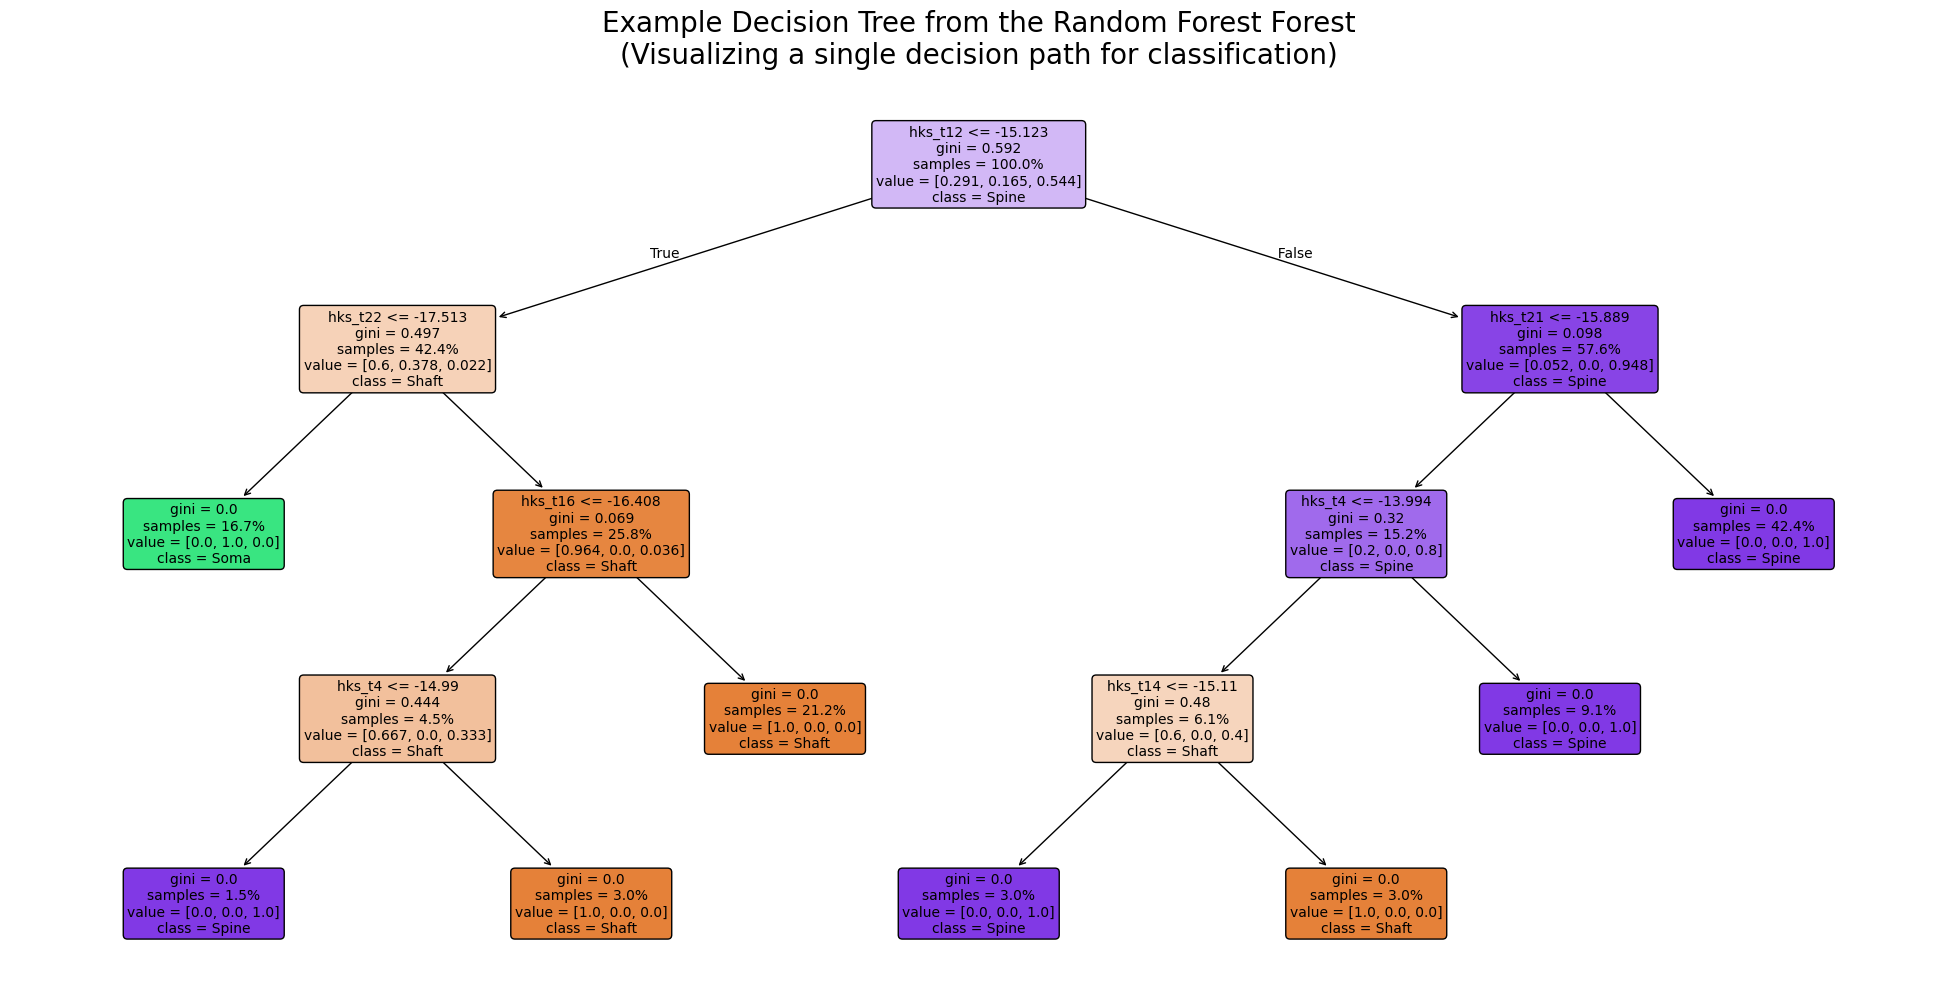

In [25]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

# 1. Select a single tree from the trained forest (e.g., the first one)
# clf.estimators_ contains all 100 trees
sub_tree = clf.estimators_[0]

# 2. Create a clean, high-resolution visualization
plt.figure(figsize=(25, 12), dpi=100)

plot_tree(
    sub_tree, 
    feature_names=X.columns,    # This shows 'hks_t0', 'hks_t1', etc.
    class_names=clf.classes_,   # This shows 'Spine', 'Shaft', 'Soma'
    filled=True,                # Colors nodes based on the majority class
    rounded=True,               # Aesthetic rounded corners
    proportion=True,            # Shows percentages rather than raw counts
    precision=3,                # Number of decimals for the threshold
    fontsize=10
)

plt.title("Example Decision Tree from the Random Forest Forest\n(Visualizing a single decision path for classification)", fontsize=20)
plt.show()


# Search for larger dataset of neurons with synapse_target_structures

In [1]:
import pandas as pd
import numpy as np
import ast
import scipy.spatial
from caveclient import CAVEclient
from cloudvolume import CloudVolume
from meshparty import trimesh_io
from meshmash import condensed_hks_pipeline

client = CAVEclient('minnie65_public')
cv = CloudVolume(client.info.segmentation_source(), use_https=True)
client.materialize.get_tables()

['synapses_pni_2',
 'nucleus_detection_v0',
 'vortex_manual_nodes_of_ranvier',
 'bodor_pt_target_proofread',
 'baylor_gnn_cell_type_fine_model_v2',
 'nucleus_alternative_points',
 'nucleus_functional_area_assignment',
 'coregistration_auto_phase3_fwd_apl_vess_combined_v2',
 'aibs_metamodel_mtypes_v661_v2_corrections',
 'vortex_thalamic_proofreading_status',
 'allen_column_mtypes_v2',
 'proofreading_status_and_strategy',
 'bodor_pt_cells',
 'aibs_metamodel_mtypes_v661_v2',
 'aibs_metamodel_celltypes_v661_corrections',
 'vortex_microglia_proofreading_status',
 'allen_v1_column_types_slanted_ref',
 'multi_input_spine_predictions_ssa',
 'aibs_column_nonneuronal_ref',
 'nucleus_ref_neuron_svm',
 'synapse_target_structure',
 'myelin_auto_tags_2points',
 'apl_functional_coreg_vess_fwd',
 'vortex_axon_backtrace_column',
 'cell_type_multifeature_combo',
 'vortex_compartment_targets',
 'baylor_log_reg_cell_type_coarse_v1',
 'vortex_synapse_reattachment',
 'coregistration_auto_phase3_fwd_v2',
 's

In [13]:
# client.materialize.get_table_metadata('synapse_target_predictions_ssa') #Ben's data references vortex_compartment_targets
# client.materialize.get_table_metadata('vortex_compartment_targets')
# vortex_df = client.materialize.query_table('vortex_compartment_targets',filter_equal_dict={'valid': True},
#     limit=1000)


# # vortex_df = vortex_df[['post_pt_root_id', 'tag', 'post_pt_position']]
# # vortex_df.head()
# vortex_df.columns

# counts = vortex_df['post_pt_root_id'].value_counts(ascending=False)
# counts.head()
# unique = vortex_df['post_pt_root_id'].unique()
# print(unique)

# take a few 23P excitatory neurons with different root IDs, compute HKS on each, store label values in y
# need 1 test across neurons and 1 test mixing neurons and assessing variability, preferably HKS on terms with least connections

# 1. Pull the data (remove limit to get the full distribution)
vortex_df = client.materialize.query_table(
    'vortex_compartment_targets',
    filter_equal_dict={'valid': True}
)

# 2. Keep only the necessary columns
vortex_df = vortex_df[['id', 'post_pt_root_id', 'tag', 'post_pt_position']]

# 3. Get the counts in ascending order
counts = vortex_df['post_pt_root_id'].value_counts(ascending=True)

# 4. Format it into a clean dataframe for viewing
counts_df = counts.reset_index()
counts_df.columns = ['post_pt_root_id', 'annotation_count']

# Display the first 30 rows to assess your options
print("Neurons sorted by fewest annotations:")
display(counts_df.tail(30))

# Tip: If you want to see the most connected neurons, just use counts_df.tail(30)


Table Owner Notice on vortex_compartment_targets: Manual labeling performed as part of VORTEX. Table is undergoing updates.


Neurons sorted by fewest annotations:


,post_pt_root_id,annotation_count
21952,864691135442071368,51
21953,864691135257638831,52
21954,864691137198691137,52
21955,864691135294152460,52
21956,864691136618688219,53
21957,864691135726939455,53
21958,864691135349839831,53
21959,864691135993185985,54
21960,864691135323862684,54
21961,864691135280028065,54


In [8]:
import numpy as np
import pandas as pd
import cloudvolume
import trimesh  # Using meshparty for the base mesh
from meshparty import trimesh_io

from meshmash.cave import get_synapse_mapping
from meshmash.pipeline import chunked_hks_pipeline
from meshmash.utils import project_points_to_mesh

import annotation_utils
import importlib
importlib.reload(annotation_utils)

def get_hks_for_synapses(
    synapse_df, root_ids, mesh_dict, client, distance_threshold=1000, 
    mapping_column="ctr_pt_position", side="post"
):
    results = {}
    for root_id in root_ids:
        print(f"\nProcessing root_id: {root_id}")
        if root_id not in mesh_dict:
            continue
        
        mesh = mesh_dict[root_id]
        
        # 1. Map synapses to the original, full-resolution mesh
        synapse_mesh_mapping = get_synapse_mapping(
            root_id, mesh, client,
            distance_threshold=distance_threshold,
            mapping_column=mapping_column,
            side=side,
        )
        
        if len(synapse_mesh_mapping) == 0:
            print(f"  No synapses mapped.")
            continue
        
        original_synapse_indices = synapse_mesh_mapping[:, 1].astype(np.int64)
        print(f"  Mapped {len(original_synapse_indices)} synapses. Running HKS pipeline...")
        
        # Extract raw arrays for Cython
        raw_vertices = np.array(mesh.vertices, dtype=np.float32)
        raw_faces = np.array(mesh.faces, dtype=np.int64)
        
        # 2. BYPASS THE BUG: Set query_indices=None 
        hks_result = chunked_hks_pipeline(
            mesh=(raw_vertices, raw_faces), 
            query_indices=None,  # <--- This prevents the crash!
            simplify_agg=7,
            simplify_target_reduction=0.7, 
            overlap_distance=20_000,
            verbose=True,
        )
        
        # 3. LOOK UP THE FEATURES AFTERWARDS
        # hks_result.mapping translates original indices to simplified indices
        simplified_synapse_indices = hks_result.mapping[original_synapse_indices]
        
        # Drop any synapses that were completely deleted during simplification (-1)
        valid_mask = simplified_synapse_indices != -1
        valid_simplified_indices = simplified_synapse_indices[valid_mask]
        
        # Extract just the features for our synapses
        # hks_result.simple_features contains the computed data
        synapse_features = hks_result.simple_features.iloc[valid_simplified_indices]
        
        results[root_id] = {
            'synapse_mapping': synapse_mesh_mapping[valid_mask], 
            'hks_result': hks_result,
            'synapse_features': synapse_features
        }
        print(f"  Success! Extracted features for {len(valid_simplified_indices)} synapses.")
        
    return results

In [ ]:
# --- Execution Block ---
client.version = 1300
all_root_ids = np.array(vortex_df['post_pt_root_id'])

# Grab a small batch and convert to list!
test_root_ids = all_root_ids[1:3].tolist() 
mesh_dict = {}

cv_path = client.info.segmentation_source()
cv = cloudvolume.CloudVolume(cv_path, use_https=True, progress=True)

print(f"\nBatch fetching meshes for: {test_root_ids}")

try:
    # 1. BATCH DOWNLOAD (Fast parallel fetching)
    batch_mesh_data = cv.mesh.get(test_root_ids, fuse=False)
    
    # 2. Iterate through the downloaded batch
    for root_id, mesh_data in batch_mesh_data.items():
        print(f"\nProcessing downloaded mesh for {root_id}...")
        
        if isinstance(mesh_data, dict):
            all_vertices, all_faces, vertex_offset = [], [], 0
            for chunk_id, sub_mesh in mesh_data.items():
                v = sub_mesh.vertices if hasattr(sub_mesh, 'vertices') else sub_mesh['vertices']
                f = sub_mesh.faces if hasattr(sub_mesh, 'faces') else sub_mesh['faces']
                
                all_vertices.append(np.array(v))
                all_faces.append(np.array(f).reshape(-1, 3) + vertex_offset) 
                vertex_offset += len(v)
                
            final_vertices = np.vstack(all_vertices)
            final_faces = np.vstack(all_faces)
            
            # --- THE HEALING CHAMBER ---
            print("  Healing mesh seams...")
            temp_mesh = trimesh.Trimesh(vertices=final_vertices, faces=final_faces, process=True)
            
            # Extract and cast explicitly
            clean_v = np.array(temp_mesh.vertices, dtype=np.float32)
            clean_f = np.array(temp_mesh.faces, dtype=np.int64)
            
            # Lock into meshparty safely
            m = trimesh_io.Mesh(vertices=clean_v, faces=clean_f, process=False)
            
        elif hasattr(mesh_data, 'vertices'):
            print("  Healing standard mesh...")
            temp_mesh = trimesh.Trimesh(
                vertices=np.array(mesh_data.vertices), 
                faces=np.array(mesh_data.faces).reshape(-1, 3), 
                process=True
            )
            clean_v = np.array(temp_mesh.vertices, dtype=np.float32)
            clean_f = np.array(temp_mesh.faces, dtype=np.int64)
            m = trimesh_io.Mesh(vertices=clean_v, faces=clean_f, process=False)
            
        mesh_dict[root_id] = m
        print(f"  Successfully loaded locked & clean mesh: {len(m.vertices)} vertices")
        
except Exception as e:
    print(f"Batch processing failed: {e}")

# Run pipeline
results = get_hks_for_synapses(vortex_df, test_root_ids, mesh_dict, client)

for root_id, data in results.items():
    hks_features = data['hks_result'].simple_features
    print(f"Root {root_id}: {len(hks_features)} HKS features computed")


Batch fetching meshes for: [864691136741412444, 864691135133443232]



Processing downloaded mesh for 864691135133443232...
  Healing standard mesh...


  Successfully loaded locked & clean mesh: 2013849 vertices

Processing downloaded mesh for 864691136741412444...
  Healing standard mesh...
  Successfully loaded locked & clean mesh: 727644 vertices

Processing root_id: 864691136741412444


C:\Users\bkrou\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\meshmash\cave.py:85: RuntimeWarning: Engine has switched to 'python' because numexpr does not support extension array dtypes. Please set your engine to python manually.
  synapses.query("pre_pt_root_id != post_pt_root_id", inplace=True)


  Mapped 943 synapses. Running HKS pipeline...
Subdividing mesh...
Meshes in queue: 1
Finding overlapping submeshes...
Computing HKS across submeshes...


...

C:\Users\bkrou\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\meshmash\cave.py:85: RuntimeWarning: Engine has switched to 'python' because numexpr does not support extension array dtypes. Please set your engine to python manually.
  synapses.query("pre_pt_root_id != post_pt_root_id", inplace=True)


  Mapped 4139 synapses. Running HKS pipeline...
Subdividing mesh...
Meshes in queue: 2
Finding overlapping submeshes...
Computing HKS across submeshes...


Applying function compute_hks:   0%|          | 0/48 [00:00<?, ?it/s]

Applying function agglomerate_mesh:   0%|          | 0/48 [00:00<?, ?it/s]

  Success! Extracted features for 4139 synapses.
Root 864691136741412444: 214641 HKS features computed
Root 864691135133443232: 593367 HKS features computed


# ML model on Pre-Annotated Neurons

Note: We will not be training on the neurons with 5000 connections, neurons will have 50-75 connections for even split.

In [19]:
# 1. Pull the data from the vortex_compartment_targets table
# (You might want to remove the limit=1000 if you want the whole dataset!)
vortex_df = client.materialize.query_table(
    'vortex_compartment_targets',
    filter_equal_dict={'valid': True}
)

# 2. Keep only the columns your ML model cares about
vortex_df = vortex_df[['id', 'post_pt_root_id', 'tag', 'post_pt_position']]

# 3. Find the neurons with the LEAST connections
counts = vortex_df['post_pt_root_id'].value_counts(ascending=True)

# Let's grab the 3 neurons with the fewest synapses for your test
test_root_ids = counts.iloc[-30:-7].index.to_list()
print(f"Testing on the following root IDs: {test_root_ids}")

Table Owner Notice on vortex_compartment_targets: Manual labeling performed as part of VORTEX. Table is undergoing updates.


Testing on the following root IDs: [864691135465381701, 864691135294152460, 864691135257638831, 864691137198691137, 864691135726939455, 864691136618688219, 864691135349839831, 864691136420507799, 864691135323862684, 864691135993185985, 864691135280028065, 864691134886156026, 864691136725071101, 864691136335150259, 864691136966961614, 864691135947023969, 864691135594774315, 864691135464946757, 864691135134029728, 864691135489514810, 864691135849279070, 864691135430270512, 864691135778700477]


In [ ]:
# --- Execution Block ---
client.version = 1300

mesh_dict = {}

cv_path = client.info.segmentation_source()
cv = cloudvolume.CloudVolume(cv_path, use_https=True, progress=True)

try:
    # 1. BATCH DOWNLOAD (Fast parallel fetching)
    batch_mesh_data = cv.mesh.get(test_root_ids, fuse=False)
    
    # 2. Iterate through the downloaded batch
    for root_id, mesh_data in batch_mesh_data.items():
        print(f"\nProcessing downloaded mesh for {root_id}...")
        
        if isinstance(mesh_data, dict):
            all_vertices, all_faces, vertex_offset = [], [], 0
            for chunk_id, sub_mesh in mesh_data.items():
                v = sub_mesh.vertices if hasattr(sub_mesh, 'vertices') else sub_mesh['vertices']
                f = sub_mesh.faces if hasattr(sub_mesh, 'faces') else sub_mesh['faces']
                
                all_vertices.append(np.array(v))
                all_faces.append(np.array(f).reshape(-1, 3) + vertex_offset) 
                vertex_offset += len(v)
                
            final_vertices = np.vstack(all_vertices)
            final_faces = np.vstack(all_faces)
            
            # --- THE HEALING CHAMBER ---
            print("  Healing mesh seams...")
            temp_mesh = trimesh.Trimesh(vertices=final_vertices, faces=final_faces, process=True)
            
            # Extract and cast explicitly
            clean_v = np.array(temp_mesh.vertices, dtype=np.float32)
            clean_f = np.array(temp_mesh.faces, dtype=np.int64)
            
            # Lock into meshparty safely
            m = trimesh_io.Mesh(vertices=clean_v, faces=clean_f, process=False)
            
        elif hasattr(mesh_data, 'vertices'):
            print("  Healing standard mesh...")
            temp_mesh = trimesh.Trimesh(
                vertices=np.array(mesh_data.vertices), 
                faces=np.array(mesh_data.faces).reshape(-1, 3), 
                process=True
            )
            clean_v = np.array(temp_mesh.vertices, dtype=np.float32)
            clean_f = np.array(temp_mesh.faces, dtype=np.int64)
            m = trimesh_io.Mesh(vertices=clean_v, faces=clean_f, process=False)
            
        mesh_dict[root_id] = m
        print(f"  Successfully loaded locked & clean mesh: {len(m.vertices)} vertices")
        
except Exception as e:
    print(f"Batch processing failed: {e}")

    # Run pipeline
    results = get_hks_for_synapses(vortex_df, test_root_ids, mesh_dict, client)

    for root_id, data in results.items():
        hks_features = data['hks_result'].simple_features
        print(f"Root {root_id}: {len(hks_features)} HKS features computed")


Processing downloaded mesh for 864691135294152460...
  Healing standard mesh...


  Successfully loaded locked & clean mesh: 2607226 vertices

Processing downloaded mesh for 864691136420507799...
  Healing standard mesh...
  Successfully loaded locked & clean mesh: 2830352 vertices

Processing downloaded mesh for 864691135323862684...
  Healing standard mesh...
  Successfully loaded locked & clean mesh: 2273650 vertices

Processing downloaded mesh for 864691135134029728...
  Healing standard mesh...
  Successfully loaded locked & clean mesh: 2509815 vertices

Processing downloaded mesh for 864691135280028065...
  Healing standard mesh...
  Successfully loaded locked & clean mesh: 1925967 vertices

Processing downloaded mesh for 864691135594774315...
  Healing standard mesh...
  Successfully loaded locked & clean mesh: 3670130 vertices

Processing downloaded mesh for 864691135257638831...
  Healing standard mesh...
  Successfully loaded locked & clean mesh: 3868627 vertices

Processing downloaded mesh for 864691135430270512...
  Healing standard mesh...
  Successfull

C:\Users\bkrou\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\meshmash\cave.py:85: RuntimeWarning: Engine has switched to 'python' because numexpr does not support extension array dtypes. Please set your engine to python manually.
  synapses.query("pre_pt_root_id != post_pt_root_id", inplace=True)


  Mapped 6863 synapses. Running HKS pipeline...
Subdividing mesh...
Meshes in queue: 21
Meshes in queue: 13
Meshes in queue: 24
Finding overlapping submeshes...
Computing HKS across submeshes...


Applying function compute_hks:   0%|          | 0/154 [00:00<?, ?it/s]

...

C:\Users\bkrou\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\meshmash\cave.py:85: RuntimeWarning: Engine has switched to 'python' because numexpr does not support extension array dtypes. Please set your engine to python manually.
  synapses.query("pre_pt_root_id != post_pt_root_id", inplace=True)


  Mapped 7240 synapses. Running HKS pipeline...
Subdividing mesh...
Meshes in queue: 154
Meshes in queue: 107
Meshes in queue: 57
Meshes in queue: 7
Meshes in queue: 12
Meshes in queue: 1
Finding overlapping submeshes...
Computing HKS across submeshes...


Applying function compute_hks:   0%|          | 0/253 [00:00<?, ?it/s]

Applying function agglomerate_mesh:   0%|          | 0/253 [00:00<?, ?it/s]

  Success! Extracted features for 7213 synapses.
Root 864691135465381701: 1980911 HKS features computed
Root 864691135294152460: 777698 HKS features computed
Root 864691135257638831: 1156794 HKS features computed
Root 864691137198691137: 969172 HKS features computed
Root 864691135726939455: 1264418 HKS features computed
Root 864691136618688219: 2039724 HKS features computed
Root 864691135349839831: 1188587 HKS features computed
Root 864691136420507799: 845302 HKS features computed
Root 864691135323862684: 678731 HKS features computed
Root 864691135993185985: 1332358 HKS features computed
Root 864691135280028065: 572476 HKS features computed
Root 864691134886156026: 1715216 HKS features computed
Root 864691136725071101: 492038 HKS features computed
Root 864691136335150259: 1732703 HKS features computed
Root 864691136966961614: 2081324 HKS features computed
Root 864691135947023969: 1716215 HKS features computed
Root 864691135594774315: 1095843 HKS features computed
Root 86469113546494675

In [ ]:
from scipy.spatial import cKDTree
import numpy as np
import pandas as pd

all_ml_data = []

# CAVE usually returns points in voxels. Meshes are in nanometers.
# This multiplier converts voxel coordinates to nanometers.
# (If your dataset uses a different resolution, adjust this!)
RESOLUTION = np.array([4, 4, 40]) 

for root_id, data in results.items():
    
    # 1. Filter your ground truth dataframe for just this neuron
    neuron_df = vortex_df[vortex_df['post_pt_root_id'] == root_id].copy()
    
    if len(neuron_df) == 0:
        continue
        
    # 2. Extract the 3D coordinates of your manual annotations
    # Stack them into a 2D array and convert to nanometers
    pts = np.vstack(neuron_df['post_pt_position'].values)
    
    # Quick heuristic check: if coordinates are tiny, they need voxel-to-nm conversion
    if pts[0][0] < 1000000: 
        pts = pts * RESOLUTION
        
    # 3. Get the original mesh we stored in memory earlier
    original_mesh = mesh_dict[root_id]
    original_vertices = np.array(original_mesh.vertices)
    
    # 4. Use a KDTree to find the closest mesh vertex to each manual annotation
    tree = cKDTree(original_vertices)
    distances, original_vertex_indices = tree.query(pts)
    
    # 5. Translate that original vertex to the simplified mesh vertex
    hks_result = data['hks_result']
    mapping_array = hks_result.mapping
    simplified_vertex_indices = mapping_array[original_vertex_indices]
    
    # Filter out any points that landed on geometry that was deleted during simplification (-1)
    valid_mask = simplified_vertex_indices != -1
    valid_neuron_df = neuron_df[valid_mask].reset_index(drop=True)
    valid_simplified_indices = simplified_vertex_indices[valid_mask]
    
    # 6. Extract the 32 computed HKS features for these specific vertices
    hks_features = hks_result.simple_features.iloc[valid_simplified_indices].reset_index(drop=True)
    
    # 7. Glue the labels (tag) side-by-side with the math (HKS)
    combined_df = pd.concat([valid_neuron_df, hks_features], axis=1)
    
    all_ml_data.append(combined_df)

# 8. Create the final, master ML dataset
if len(all_ml_data) > 0:
    ml_ready_df = pd.concat(all_ml_data, ignore_index=True)
    print(f"Successfully built ML dataset with {len(ml_ready_df)} annotated targets.")
    print(ml_ready_df.shape)
else:
    print("No data matched! Make sure vortex_df contains the neurons you processed.")

Successfully built ML dataset with 1325 annotated targets.
(1325, 36)


In [48]:
ml_ready_df.head(10)
ml_ready_df['post_pt_root_id'].unique()

<IntegerArray>
[864691135465381701, 864691135294152460, 864691135257638831,
 864691137198691137, 864691135726939455, 864691136618688219,
 864691135349839831, 864691136420507799, 864691135323862684,
 864691135993185985, 864691135280028065, 864691134886156026,
 864691136725071101, 864691136335150259, 864691136966961614,
 864691135947023969, 864691135594774315, 864691135464946757,
 864691135134029728, 864691135489514810, 864691135849279070,
 864691135430270512, 864691135778700477]
Length: 23, dtype: Int64

In [56]:
ml_ready_df.to_csv('ml_ready.csv', index=False)

# ML Model

In [51]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GroupKFold
from sklearn.metrics import accuracy_score, classification_report
import numpy as np

# 1. Filter the dataframe to keep only valid labels
valid_labels = ['spine', 'shaft', 'soma']
filtered_ml_df = ml_ready_df[ml_ready_df['tag'].isin(valid_labels)].copy()

# 2. Define Features (X), Labels (y), and Groups (Neuron IDs)
feature_cols = [col for col in filtered_ml_df.columns if col.startswith('hks')]
X = filtered_ml_df[feature_cols]
y = filtered_ml_df['tag']
groups = filtered_ml_df['post_pt_root_id']

print(f"Total dataset: {groups.nunique()} neurons ({len(X)} total compartments)")
print("-" * 60)

# 3. Setup the GroupKFold and tracking variables
gkf = GroupKFold(n_splits=5)
ensemble_models = []
fold_accuracies = []

# To generate one final clean classification report, we'll store all predictions
all_y_true = []
all_y_pred = []

# 4. The K-Fold Loop (Strict Neuron Holdouts)
for fold, (train_idx, test_idx) in enumerate(gkf.split(X, y, groups=groups), 1):
    
    # Split the data based on the indices sklearn provides
    X_train_fold, X_test_fold = X.iloc[train_idx], X.iloc[test_idx]
    y_train_fold, y_test_fold = y.iloc[train_idx], y.iloc[test_idx]
    
    # Initialize and train the model for this specific fold
    clf = RandomForestClassifier(n_estimators=100, max_depth=5, class_weight='balanced', random_state=42)
    clf.fit(X_train_fold, y_train_fold)
    
    # Evaluate strictly on the holdout neurons
    y_pred = clf.predict(X_test_fold)
    acc = accuracy_score(y_test_fold, y_pred)
    
    # Store metrics and model
    fold_accuracies.append(acc)
    ensemble_models.append(clf)
    
    # Store predictions for the overall report
    all_y_true.extend(y_test_fold)
    all_y_pred.extend(y_pred)
    
    # Print out how this specific fold did
    num_test_neurons = filtered_ml_df.iloc[test_idx]['post_pt_root_id'].nunique()
    print(f"Fold {fold}: Tested on {num_test_neurons} entirely new neurons (Accuracy: {acc:.2%})")

# 5. Final Overall Evaluation
print("-" * 60)
print(f"Average True Holdout Accuracy: {np.mean(fold_accuracies):.2%}")
print(f"Standard Deviation:            {np.std(fold_accuracies):.2%}\n")

print("Overall Classification Report (Across all holdout folds):")
print(classification_report(all_y_true, all_y_pred))

Total dataset: 23 neurons (1318 total compartments)
------------------------------------------------------------
Fold 1: Tested on 4 entirely new neurons (Accuracy: 97.45%)
Fold 2: Tested on 4 entirely new neurons (Accuracy: 93.64%)
Fold 3: Tested on 5 entirely new neurons (Accuracy: 92.61%)
Fold 4: Tested on 5 entirely new neurons (Accuracy: 92.91%)
Fold 5: Tested on 5 entirely new neurons (Accuracy: 88.26%)
------------------------------------------------------------
Average True Holdout Accuracy: 92.97%
Standard Deviation:            2.93%

Overall Classification Report (Across all holdout folds):
              precision    recall  f1-score   support

       shaft       0.94      0.95      0.94       835
        soma       0.92      0.97      0.94       148
       spine       0.91      0.85      0.88       335

    accuracy                           0.93      1318
   macro avg       0.92      0.92      0.92      1318
weighted avg       0.93      0.93      0.93      1318



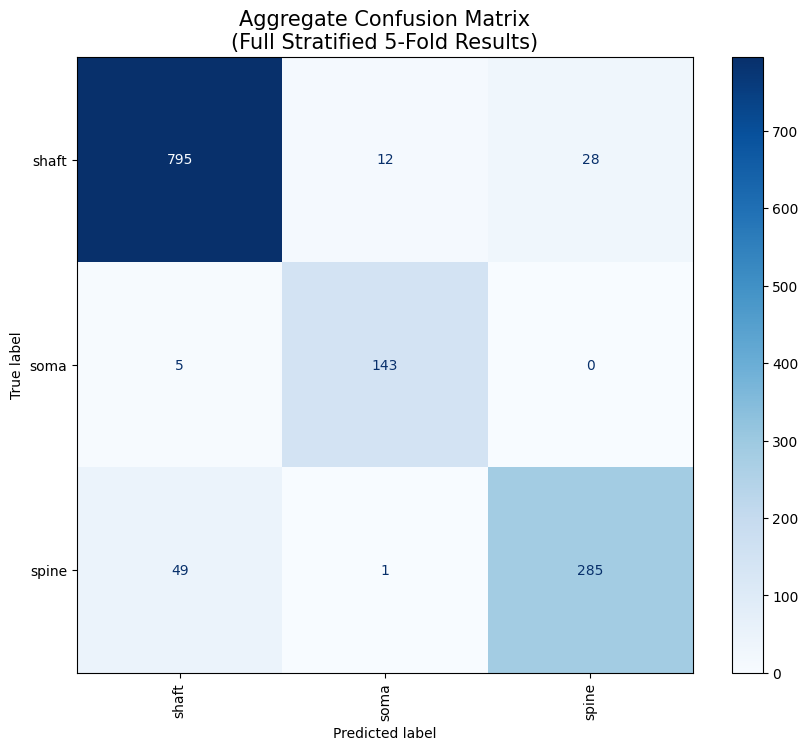

In [53]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

# Create a high-quality visualization of results from ALL folds
fig, ax = plt.subplots(figsize=(10, 8))

# from_predictions is used here because we aggregated the results in the loop above
cmp = ConfusionMatrixDisplay.from_predictions(
    all_y_true, 
    all_y_pred, 
    display_labels=clf.classes_, # Uses the labels from the last trained model
    cmap='Blues',                # Using a higher-contrast vibrant palette
    xticks_rotation='vertical',
    ax=ax
)

plt.title("Aggregate Confusion Matrix\n(Full Stratified 5-Fold Results)", fontsize=15)
plt.grid(False) 
plt.show()